# 14 · Crop rotations

Run the stock Kellogg Biological Station sequence to follow crop yields and soil organic carbon through successive crops and fallows.

## You will learn

- Recognize crops and fallows as rotation components of one treatment.
- Run an unchanged sequence and compare component yields over time.
- Follow soil organic carbon across component ends and explore one crop's results.

In [1]:
LESSON = "14_rotations"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load the tools for tables and inline plots.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Preview the first six rotation components and locate the copied inputs in `runs/`.

In [4]:
# Preview the sequence and identify its copied inputs.
filex = RUNS / "MSKB8902.SQX"
lines = filex.read_text(encoding="utf-8").splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith("*TREATMENTS"))
end = next(i for i in range(start + 1, len(lines)) if lines[i].startswith("*"))
component_lines = [line for line in lines[start + 2:end] if line.strip()]
print("Inputs:", filex.relative_to(HERE).as_posix(), "and", (RUNS / "SOIL.SOL").relative_to(HERE).as_posix())
print("Weather files:", len(list(RUNS.glob("MSKB*.WTH"))), "(1989-2016)")
print("Rotation components in the FileX:", len(component_lines))
print("\n".join(lines[start:start + 2] + component_lines[:6]))

Inputs: runs/MSKB8902.SQX and runs/SOIL.SOL
Weather files: 28 (1989-2016)
Rotation components in the FileX: 56
*TREATMENTS                        -------------FACTOR LEVELS------------
@N R O C TNAME.................... CU FL SA IC MP MI MF MR MC MT ME MH SM
 1 1 1 0 LTER TREAT 1 HI MZ GL582   6  1  0  1  1  0  1  0  0  1  0  1  1
 1 2 1 0 LTER TREAT 1 HI FA         2  1  0  0  2  0  0  0  0  2  0  2  1
 1 3 1 0 LTER TREAT 1 HI SB PI9272  3  1  0  0  3  0  0  0  0  0  0  3  1
 1 4 1 0 LTER TREAT 1 HI FA         2  1  0  0  4  0  0  0  0  3  0  4  1
 1 5 1 0 LTER TREAT 1 HI MZ GL220   6  1  0  0  5  0  2  0  0  0  0  5  1
 1 6 1 0 LTER TREAT 1 HI FA         2  1  0  0  6  0  0  0  0  4  0  6  1


🌱 Crop idea  
`N` stays 1 while `R` numbers the components; `MZ` = maize, `SB` = soybean and `FA` = fallow.
A sequence carries soil water and nitrogen into the next component; it does not restart the soil each season.

Run treatment 1 unchanged; `run()` detects the sequence and selects DSSAT mode `Q`.

In [5]:
# Run the stock sequence and locate its collected outputs.
result = dl.run(filex, treatment=1, executable=dssat)
print("DSSAT exit status:", result.returncode)
print("Run directory:", result.run_dir.relative_to(HERE).as_posix())
print("Outputs:", ", ".join(path.name for path in result.outputs))

DSSAT exit status: 0
Run directory: runs/dssat_run_2026-10-06_202720
Outputs: DSSAT48.INH, DSSAT48.INP, DSSBatch.v48, GHG.OUT, INFO.OUT, LUN.LST, Leaves.OUT, MSKB8902.OEB, MSKB8902.OEV, MSKB8902.OG2, MSKB8902.OGF, MSKB8902.OLC, MSKB8902.OLN, MSKB8902.OME, MSKB8902.OMO, MSKB8902.ONO, MSKB8902.OOV, MSKB8902.OPC, MSKB8902.OPG, MSKB8902.OPN, MSKB8902.OSC, MSKB8902.OSN, MSKB8902.OSU, MSKB8902.OSW, MSKB8902.OTS, MSKB8902.OWE, Mulch.OUT, OUTPUT.LST, PlantNBal.OUT, Plantsum.OUT, RunList.OUT, SWBalSum.OUT, SoilCBal.OUT, SoilCBalSum.OUT, SoilNBalSum.OUT, SoilNiBal.OUT, SoilNoBal.OUT, SoilWatBal.OUT, SoilWater.OUT, WARNING.OUT


🐍 Python idea  
This stock case uses `run()` because `Simulation` rejects changes in station elevation and duplicate dates in its weather files.
The lesson keeps those stock files unchanged, as required by this case.

Inspect a compact warning summary because a zero exit status can still accompany stock-input warnings.

In [6]:
# Show selected stock-input warnings and check for missing weather.
warning_text = (result.run_dir / "WARNING.OUT").read_text(encoding="utf-8")
messages = [line.strip() for line in warning_text.splitlines()
            if any(phrase in line for phrase in (
                "Saturated hydraulic conductivity equal to zero",
                "User-specified tillage depth greater",
                "Warning: SRAD < 1"))]
print("\n".join(dict.fromkeys(messages)))
print("Missing-weather warning:", "Weather record not found" in warning_text)

Saturated hydraulic conductivity equal to zero for one or more soil layers.
User-specified tillage depth greater than that specified by tillage implement.
Missing-weather warning: False


Read the Summary and preview six rows to distinguish cropped and fallow components.

In [7]:
# Read the component results and preview crops and fallows.
summary = dl.to_dataframe(dl.read_summary(result.run_dir))
summary[["TRNO", "R#", "CR", "SDAT", "PDAT", "HDAT", "HWAM"]].head(6)

,TRNO,R#,CR,SDAT,PDAT,HDAT,HWAM
0,1,1,MZ,1989-03-01,1989-05-04,1989-10-23,8028
1,1,2,FA,1989-10-24,None,1990-05-28,0
2,1,3,SB,1990-05-29,1990-05-29,1990-10-17,3611
3,1,4,FA,1990-10-18,None,1991-06-14,0
4,1,5,MZ,1991-06-15,1991-06-15,1991-10-10,7234
5,1,6,FA,1991-10-11,None,1992-05-17,0


🌱 Crop idea  
`R#` links a Summary row to its FileX component; fallow has zero harvested yield and no planting date.
The run returns 55 rows (28 crops and 27 fallows): it finishes wheat component 55 in July 2016 after crossing the 27-year stopping boundary, before fallow component 56.

Select the cropped components to display planting, harvest and grain yield (`HWAM`, kg/ha) across the sequence.

In [8]:
# Display each cropped component without the fallow zero yields.
crops = summary.loc[summary["CR"] != "FA", ["R#", "CR", "PDAT", "HDAT", "HWAM"]].copy()
crops

,R#,CR,PDAT,HDAT,HWAM
0,1,MZ,1989-05-04,1989-10-23,8028
2,3,SB,1990-05-29,1990-10-17,3611
4,5,MZ,1991-06-15,1991-10-10,7234
6,7,SB,1992-05-18,1992-10-26,2826
8,9,MZ,1993-05-07,1993-11-08,8911
10,11,SB,1994-05-18,1994-10-11,4196
12,13,WH,1994-10-13,1995-07-22,3571
14,15,MZ,1996-05-14,1996-11-03,3430
16,17,SB,1997-05-22,1997-10-17,1958
18,19,WH,1997-10-22,1998-07-11,2604


Plot each crop's component yields against harvest date, including winter wheat (`WH`).

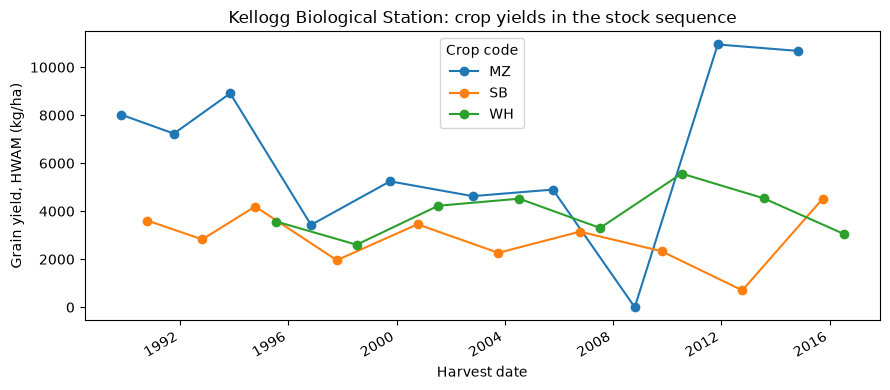

In [9]:
# Plot grain yield over time for each crop in the sequence.
fig, ax = plt.subplots(figsize=(9, 4))
for crop, rows in crops.groupby("CR"):
    ax.plot(rows["HDAT"], rows["HWAM"], marker="o", label=crop)
ax.set(xlabel="Harvest date", ylabel="Grain yield, HWAM (kg/ha)",
       title="Kellogg Biological Station: crop yields in the stock sequence")
ax.legend(title="Crop code")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

🌱 Crop idea  
The zero maize yield in 2008 (component 39) looks surprising; the Summary reports zero rather than a missing value.
Yield alone does not establish its cause, and this one sequence provides no comparison that isolates a rotation effect.

Summarize yield separately by crop so fallow zeroes do not dilute crop means.

In [10]:
# Compare the count, mean and range of yields for each crop.
crop_stats = crops.groupby("CR")["HWAM"].agg(["count", "mean", "min", "max"])
crop_stats.rename(columns={"count": "Crop components", "mean": "Mean HWAM (kg/ha)",
                           "min": "Min HWAM (kg/ha)", "max": "Max HWAM (kg/ha)"}).round(1)

,Crop components,Mean HWAM (kg/ha),Min HWAM (kg/ha),Max HWAM (kg/ha)
CR,,,,
MZ,10,6400.3,0,10947
SB,10,2901.8,704,4518
WH,8,3923.6,2604,5568


Compare soil organic carbon (`OCAM`, kg C/ha) at the first and last component ends, excluding surface carbon.

In [11]:
# Display the first and last reported soil organic carbon stocks.
carbon = summary[["R#", "CR", "HDAT", "OCAM"]].copy()
carbon.iloc[[0, -1]].rename(columns={"OCAM": "Soil organic carbon (kg C/ha)"})

,R#,CR,HDAT,Soil organic carbon (kg C/ha)
0,1,MZ,1989-10-23,57886
54,55,WH,2016-07-12,71120


Plot soil organic carbon at every component end, including fallows, to follow the soil across the sequence.

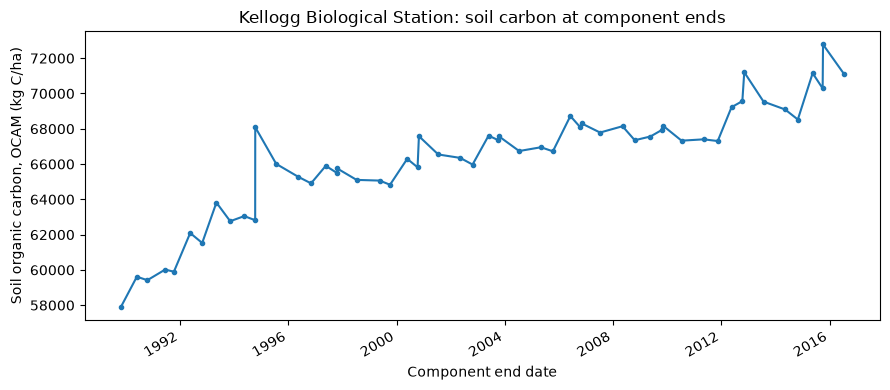

In [12]:
# Plot the soil carbon stock through successive crops and fallows.
ax = carbon.plot(x="HDAT", y="OCAM", marker=".", legend=False, figsize=(9, 4))
ax.set(xlabel="Component end date", ylabel="Soil organic carbon, OCAM (kg C/ha)",
       title="Kellogg Biological Station: soil carbon at component ends")
ax.figure.autofmt_xdate()
plt.tight_layout()
plt.show()

🌱 Crop idea  
Soil organic carbon rises from 57,886 to 71,120 kg C/ha between the first and last reported ends, a net increase of 13,234 kg C/ha with fluctuations.
These are simulated soil stocks at component ends, not daily measurements or a comparison with another rotation; the first value is after the first maize crop, not the initial stock.

## Your turn

Show every component yield for your chosen crop in a fresh run of the same sequence.

Hint: edit `chosen_crop = "MZ"` to `"SB"` (soybean) or `"WH"` (wheat), then run this cell.

In [13]:
# Choose a crop and rebuild its component-yield table from a fresh run.
chosen_crop = "MZ"
exercise_result = dl.run(RUNS / "MSKB8902.SQX", treatment=1, executable=dssat)
exercise_summary = dl.to_dataframe(dl.read_summary(exercise_result.run_dir))
exercise_summary.loc[exercise_summary["CR"] == chosen_crop,
                     ["R#", "CR", "PDAT", "HDAT", "HWAM"]]

,R#,CR,PDAT,HDAT,HWAM
0,1,MZ,1989-05-04,1989-10-23,8028
4,5,MZ,1991-06-15,1991-10-10,7234
8,9,MZ,1993-05-07,1993-11-08,8911
14,15,MZ,1996-05-14,1996-11-03,3430
20,21,MZ,1999-05-19,1999-10-05,5245
26,27,MZ,2002-05-10,2002-10-23,4628
32,33,MZ,2005-05-04,2005-10-11,4901
38,39,MZ,2008-05-09,2008-10-20,0
44,45,MZ,2011-05-09,2011-11-14,10947
50,51,MZ,2014-05-12,2014-10-30,10679


## Recap

- One sequence treatment holds numbered crop and fallow components with soil carry-over.
- `run()` detects sequence mode; Summary `R#`, `CR`, dates and `HWAM` describe each completed component.
- Crop-specific yield comparisons and soil carbon at component ends describe this sequence without isolating a rotation effect.

Guide: [Sequence analysis](../../docs/guide/sequence.md).  
Next: [15 · In-season yield forecast](../15_yield_forecast/lesson.ipynb).